In [43]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import cv2
from PIL import Image
from sklearn.model_selection import train_test_split
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
import torchvision
from torchvision import transforms as T
import torch.nn.functional as F
from torch.autograd import Variable
import albumentations as A
from torchsummary import summary
import segmentation_models_pytorch as smp
from tqdm.notebook import tqdm
import os
import time

In [44]:
## Defining paths

IMAGE_PATH = '../Datasets/LandCover/images/'
MASK_PATH = '../Datasets/LandCover/masks/'

n_classes = 5


## function to create dataframe of all images
def create_df():
    name = []
    for dirname, _, filenames in os.walk(IMAGE_PATH):
        for filename in filenames:
            name.append(filename.split('.')[0])
    

    return pd.DataFrame({'id':name}, index = np.arange(0, len(name)))


df = create_df()

print('Total Images: ', len(df))

Total Images:  41


In [45]:
#split data
X_trainval, X_test = train_test_split(df['id'].values, test_size=0.1, random_state=19)
X_train, X_val = train_test_split(X_trainval, test_size=0.15, random_state=19)

print('Train Size   : ', len(X_train))
print('Val Size     : ', len(X_val))
print('Test Size    : ', len(X_test))

Train Size   :  30
Val Size     :  6
Test Size    :  5


Image Size (9289, 8914, 3)
Mask Size (9289, 8914)


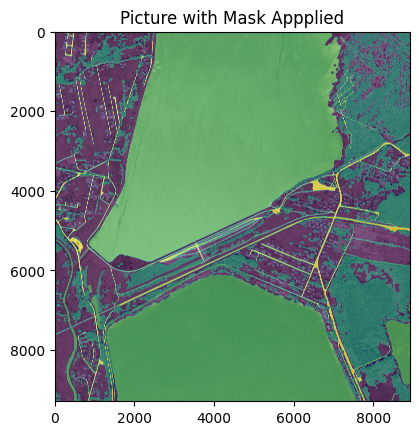

In [46]:
img = Image.open(IMAGE_PATH + df['id'][10] + '.tif')
mask = Image.open(MASK_PATH + df['id'][10] + '.tif')
print('Image Size', np.asarray(img).shape)
print('Mask Size', np.asarray(mask).shape)


plt.imshow(img)
plt.imshow(mask, alpha=0.6)
plt.title('Picture with Mask Appplied')
plt.show()

In [47]:
## Creating dataset class

class LandCover_DS(Dataset):

    def __init__(self, img_path, mask_path, X, mean, std, transform = None):
        self.img_path = img_path
        self.mask_path = mask_path
        self.mean = mean
        self.std = std
        self.transform = transform
        self.X = X

    
    def __len__(self):
        return len(self.X)

    def __getitem__(self, index):
        img = cv2.imread(self.img_path + self.X[index] + ".tif")
        mask = cv2.imread(self.mask_path + self.X[index] + ".tif", cv2.IMREAD_GRAYSCALE)

        if self.transform is not None:
            aug = self.transform(image = img, mask = mask)
            img = Image.fromarray(aug['image'])
            mask = aug['mask']

        if self.transform is None:
            img = Image.fromarray(img)

        
        # if mask.ndim == 4 and mask.shape[-1] > 1:
        #     mask = np.argmax(mask, axis=-1)

        t = T.Compose([T.ToTensor(), T.Normalize(self.mean, self.std)])
        img = t(img)
        mask = torch.from_numpy(mask).long()

        return img, mask

In [48]:
mean = [0.485, 0.456, 0.406]
std = [0.229, 0.224, 0.225]

t_train = A.Compose([A.Resize(height=256, width=256, interpolation=cv2.INTER_NEAREST),
                     A.HorizontalFlip(), A.VerticalFlip(), A.GridDistortion(p = 0.2),
                     A.RandomBrightnessContrast((0, 0.5),(0, 0.5)), A.GaussNoise()])

t_val = A.Compose([A.Resize(height=256,width=256, interpolation=cv2.INTER_NEAREST), A.HorizontalFlip(),
                   A.GridDistortion(p = 0.2)])


train_set = LandCover_DS(IMAGE_PATH, MASK_PATH, X_train, mean, std, t_train)
val_set = LandCover_DS(IMAGE_PATH, MASK_PATH, X_val, mean, std, t_val)

batch_size = 3

train_loader = DataLoader(train_set, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_set, batch_size=batch_size, shuffle=True)


In [49]:
model = smp.Unet('mobilenet_v2', encoder_weights='imagenet', classes=5, activation=None, encoder_depth=5, decoder_channels=[256, 128, 64, 32, 16])

In [50]:
def pixel_accuracy(output, mask):
    with torch.no_grad():
        output = torch.argmax(F.softmax(output, dim=1), dim=1)
        correct = torch.eq(output, mask).int()
        accuracy = float(correct.sum()) / float(correct.numel())
    return accuracy

In [51]:
def mIoU(pred_mask, mask, smooth=1e-10, n_classes=5):
    with torch.no_grad():
        pred_mask = F.softmax(pred_mask, dim=1)
        pred_mask = torch.argmax(pred_mask, dim=1)
        pred_mask = pred_mask.contiguous().view(-1)
        mask = mask.contiguous().view(-1)

        iou_per_class = []
        for clas in range(0, n_classes): #loop per pixel class
            true_class = pred_mask == clas
            true_label = mask == clas

            if true_label.long().sum().item() == 0: #no exist label in this loop
                iou_per_class.append(np.nan)
            else:
                intersect = torch.logical_and(true_class, true_label).sum().float().item()
                union = torch.logical_or(true_class, true_label).sum().float().item()

                iou = (intersect + smooth) / (union +smooth)
                iou_per_class.append(iou)
        return np.nanmean(iou_per_class)

In [52]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

def get_lr(optimizer):
    for param_group in optimizer.param_groups:
        return param_group['lr']

def fit(epochs, model, train_loader, val_loader, criterion, optimizer, scheduler, patch=False):
    torch.cuda.empty_cache()
    train_losses = []
    test_losses = []
    val_iou = []; val_acc = []
    train_iou = []; train_acc = []
    lrs = []
    min_loss = np.inf
    decrease = 1 ; not_improve=0

    model.to(device)
    fit_time = time.time()
    for e in range(epochs):
        since = time.time()
        running_loss = 0
        iou_score = 0
        accuracy = 0
        #training loop
        model.train()
        for i, data in enumerate(tqdm(train_loader)):
            #training phase
            image_tiles, mask_tiles = data
            if patch:
                bs, n_tiles, c, h, w = image_tiles.size()

                image_tiles = image_tiles.view(-1,c, h, w)
                mask_tiles = mask_tiles.view(-1, h, w)
            
            image = image_tiles.to(device); mask = mask_tiles.to(device);
            #forward
            output = model(image)
            print(output.shape)
            print(mask.shape)
            loss = criterion(output, mask)
            #evaluation metrics
            iou_score += mIoU(output, mask)
            accuracy += pixel_accuracy(output, mask)
            #backward
            loss.backward()
            optimizer.step() #update weight          
            optimizer.zero_grad() #reset gradient
            
            #step the learning rate
            lrs.append(get_lr(optimizer))
            scheduler.step() 
            
            running_loss += loss.item()
            
        else:
            model.eval()
            test_loss = 0
            test_accuracy = 0
            val_iou_score = 0
            #validation loop
            with torch.no_grad():
                for i, data in enumerate(tqdm(val_loader)):
                    #reshape to 9 patches from single image, delete batch size
                    image_tiles, mask_tiles = data

                    if patch:
                        bs, n_tiles, c, h, w = image_tiles.size()

                        image_tiles = image_tiles.view(-1,c, h, w)
                        mask_tiles = mask_tiles.view(-1, h, w)
                    
                    image = image_tiles.to(device); mask = mask_tiles.to(device);
                    output = model(image)
                    #evaluation metrics
                    val_iou_score +=  mIoU(output, mask)
                    test_accuracy += pixel_accuracy(output, mask)
                    #loss
                    loss = criterion(output, mask)                                  
                    test_loss += loss.item()
            
            #calculatio mean for each batch
            train_losses.append(running_loss/len(train_loader))
            test_losses.append(test_loss/len(val_loader))


            if min_loss > (test_loss/len(val_loader)):
                print('Loss Decreasing.. {:.3f} >> {:.3f} '.format(min_loss, (test_loss/len(val_loader))))
                min_loss = (test_loss/len(val_loader))
                decrease += 1
                if decrease % 5 == 0:
                    print('saving model...')
                    torch.save(model, 'Unet-Mobilenet_v2_mIoU-{:.3f}.pt'.format(val_iou_score/len(val_loader)))
                    

            if (test_loss/len(val_loader)) > min_loss:
                not_improve += 1
                min_loss = (test_loss/len(val_loader))
                print(f'Loss Not Decrease for {not_improve} time')
                if not_improve == 7:
                    print('Loss not decrease for 7 times, Stop Training')
                    break
            
            #iou
            val_iou.append(val_iou_score/len(val_loader))
            train_iou.append(iou_score/len(train_loader))
            train_acc.append(accuracy/len(train_loader))
            val_acc.append(test_accuracy/ len(val_loader))
            print("Epoch:{}/{}..".format(e+1, epochs),
                  "Train Loss: {:.3f}..".format(running_loss/len(train_loader)),
                  "Val Loss: {:.3f}..".format(test_loss/len(val_loader)),
                  "Train mIoU:{:.3f}..".format(iou_score/len(train_loader)),
                  "Val mIoU: {:.3f}..".format(val_iou_score/len(val_loader)),
                  "Train Acc:{:.3f}..".format(accuracy/len(train_loader)),
                  "Val Acc:{:.3f}..".format(test_accuracy/len(val_loader)),
                  "Time: {:.2f}m".format((time.time()-since)/60))
        
    history = {'train_loss' : train_losses, 'val_loss': test_losses,
               'train_miou' :train_iou, 'val_miou':val_iou,
               'train_acc' :train_acc, 'val_acc':val_acc,
               'lrs': lrs}
    print('Total time: {:.2f} m' .format((time.time()- fit_time)/60))
    return history

In [53]:
max_lr = 1e-3
epoch = 15
weight_decay = 1e-4

criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.AdamW(model.parameters(), lr=max_lr, weight_decay=weight_decay)
sched = torch.optim.lr_scheduler.OneCycleLR(optimizer, max_lr, epochs=epoch,
                                            steps_per_epoch=len(train_loader))

history = fit(epoch, model, train_loader, val_loader, criterion, optimizer, sched)

  0%|          | 0/10 [00:00<?, ?it/s]

torch.Size([3, 5, 256, 256])
torch.Size([3, 256, 256])
torch.Size([3, 5, 256, 256])
torch.Size([3, 256, 256])
torch.Size([3, 5, 256, 256])
torch.Size([3, 256, 256])
torch.Size([3, 5, 256, 256])
torch.Size([3, 256, 256])
torch.Size([3, 5, 256, 256])
torch.Size([3, 256, 256])
torch.Size([3, 5, 256, 256])
torch.Size([3, 256, 256])
torch.Size([3, 5, 256, 256])
torch.Size([3, 256, 256])
torch.Size([3, 5, 256, 256])
torch.Size([3, 256, 256])
torch.Size([3, 5, 256, 256])
torch.Size([3, 256, 256])
torch.Size([3, 5, 256, 256])
torch.Size([3, 256, 256])


  0%|          | 0/2 [00:00<?, ?it/s]

Loss Decreasing.. inf >> 1.877 
Epoch:1/15.. Train Loss: 2.368.. Val Loss: 1.877.. Train mIoU:0.050.. Val mIoU: 0.068.. Train Acc:0.113.. Val Acc:0.188.. Time: 1.92m


  0%|          | 0/10 [00:00<?, ?it/s]

...

Loss Not Decrease for 5 time
Epoch:14/15.. Train Loss: 0.747.. Val Loss: 0.694.. Train mIoU:0.308.. Val mIoU: 0.356.. Train Acc:0.733.. Val Acc:0.741.. Time: 1.85m


  0%|          | 0/10 [00:00<?, ?it/s]

torch.Size([3, 5, 256, 256])
torch.Size([3, 256, 256])
torch.Size([3, 5, 256, 256])
torch.Size([3, 256, 256])
torch.Size([3, 5, 256, 256])
torch.Size([3, 256, 256])
torch.Size([3, 5, 256, 256])
torch.Size([3, 256, 256])
torch.Size([3, 5, 256, 256])
torch.Size([3, 256, 256])
torch.Size([3, 5, 256, 256])
torch.Size([3, 256, 256])
torch.Size([3, 5, 256, 256])
torch.Size([3, 256, 256])
torch.Size([3, 5, 256, 256])
torch.Size([3, 256, 256])
torch.Size([3, 5, 256, 256])
torch.Size([3, 256, 256])
torch.Size([3, 5, 256, 256])
torch.Size([3, 256, 256])


  0%|          | 0/2 [00:00<?, ?it/s]

Loss Decreasing.. 0.694 >> 0.620 
Epoch:15/15.. Train Loss: 0.750.. Val Loss: 0.620.. Train mIoU:0.306.. Val mIoU: 0.364.. Train Acc:0.735.. Val Acc:0.778.. Time: 1.94m
Total time: 27.80 m


In [54]:
def plot_loss(history):
    plt.plot(history['val_loss'], label='val', marker='o')
    plt.plot( history['train_loss'], label='train', marker='o')
    plt.title('Loss per epoch'); plt.ylabel('loss');
    plt.xlabel('epoch')
    plt.legend(), plt.grid()
    plt.show()
    
def plot_score(history):
    plt.plot(history['train_miou'], label='train_mIoU', marker='*')
    plt.plot(history['val_miou'], label='val_mIoU',  marker='*')
    plt.title('Score per epoch'); plt.ylabel('mean IoU')
    plt.xlabel('epoch')
    plt.legend(), plt.grid()
    plt.show()
    
def plot_acc(history):
    plt.plot(history['train_acc'], label='train_accuracy', marker='*')
    plt.plot(history['val_acc'], label='val_accuracy',  marker='*')
    plt.title('Accuracy per epoch'); plt.ylabel('Accuracy')
    plt.xlabel('epoch')
    plt.legend(), plt.grid()
    plt.show()

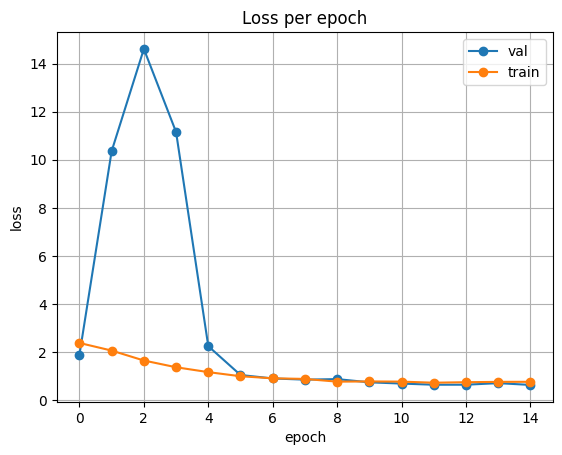

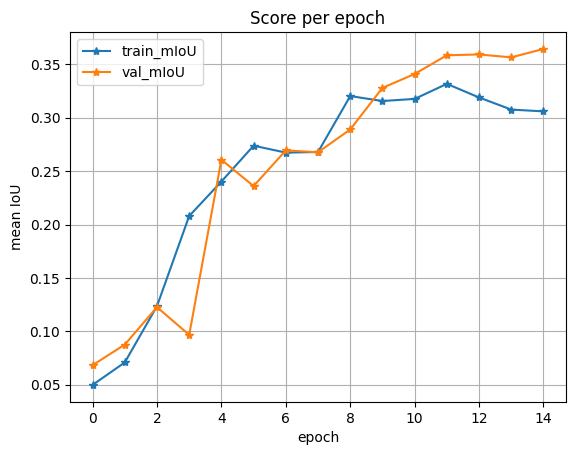

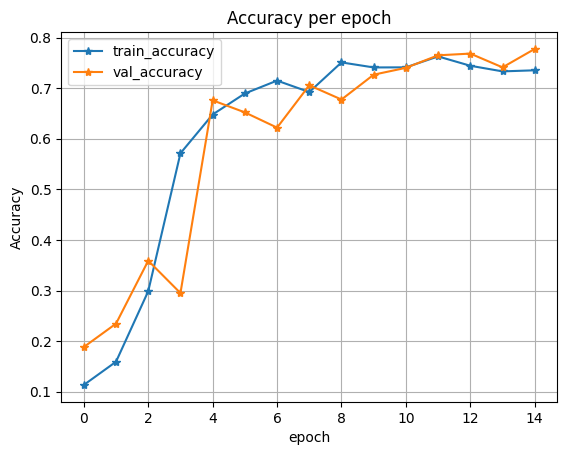

In [55]:
plot_loss(history)
plot_score(history)
plot_acc(history)

In [56]:
## Creating dataset class

class LandCoverTest_DS(Dataset):

    def __init__(self, img_path, mask_path, X, transform = None):
        self.img_path = img_path
        self.mask_path = mask_path
        self.transform = transform
        self.X = X

    
    def __len__(self):
        return len(self.X)

    def __getitem__(self, index):
        img = cv2.imread(self.img_path + self.X[index] + ".tif")
        mask = cv2.imread(self.mask_path + self.X[index] + ".tif", cv2.IMREAD_GRAYSCALE)

        if self.transform is not None:
            aug = self.transform(image = img, mask = mask)
            img = Image.fromarray(aug['image'])
            mask = aug['mask']

        if self.transform is None:
            img = Image.fromarray(img)

        
        # if mask.ndim == 4 and mask.shape[-1] > 1:
        #     mask = np.argmax(mask, axis=-1)

        # t = T.Compose([T.ToTensor(), T.Normalize(self.mean, self.std)])
        # img = t(img)
        mask = torch.from_numpy(mask).long()

        return img, mask


t_test = A.Resize(256, 256, interpolation=cv2.INTER_NEAREST)
test_set = LandCoverTest_DS(IMAGE_PATH, MASK_PATH, X_test, transform=t_test)

In [57]:
def predict_image_mask_miou(model, image, mask, mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]):
    model.eval()
    t = T.Compose([T.ToTensor(), T.Normalize(mean, std)])
    image = t(image)
    model.to(device); image=image.to(device)
    mask = mask.to(device)
    with torch.no_grad():
        
        image = image.unsqueeze(0)
        mask = mask.unsqueeze(0)
        
        output = model(image)
        score = mIoU(output, mask)
        masked = torch.argmax(output, dim=1)
        masked = masked.cpu().squeeze(0)
    return masked, score

In [58]:
def predict_image_mask_pixel(model, image, mask, mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]):
    model.eval()
    t = T.Compose([T.ToTensor(), T.Normalize(mean, std)])
    image = t(image)
    model.to(device); image=image.to(device)
    mask = mask.to(device)
    with torch.no_grad():
        
        image = image.unsqueeze(0)
        mask = mask.unsqueeze(0)
        
        output = model(image)
        acc = pixel_accuracy(output, mask)
        masked = torch.argmax(output, dim=1)
        masked = masked.cpu().squeeze(0)
    return masked, acc

In [59]:
image, mask = test_set[3]
pred_mask, score = predict_image_mask_miou(model, image, mask)

In [60]:
def miou_score(model, test_set):
    score_iou = []
    for i in tqdm(range(len(test_set))):
        img, mask = test_set[i]
        pred_mask, score = predict_image_mask_miou(model, img, mask)
        score_iou.append(score)
    return score_iou

In [61]:
mob_miou = miou_score(model, test_set)

  0%|          | 0/5 [00:00<?, ?it/s]

In [62]:
def pixel_acc(model, test_set):
    accuracy = []
    for i in tqdm(range(len(test_set))):
        img, mask = test_set[i]
        pred_mask, acc = predict_image_mask_pixel(model, img, mask)
        accuracy.append(acc)
    return accuracy

In [63]:
mob_acc = pixel_acc(model, test_set)

  0%|          | 0/5 [00:00<?, ?it/s]

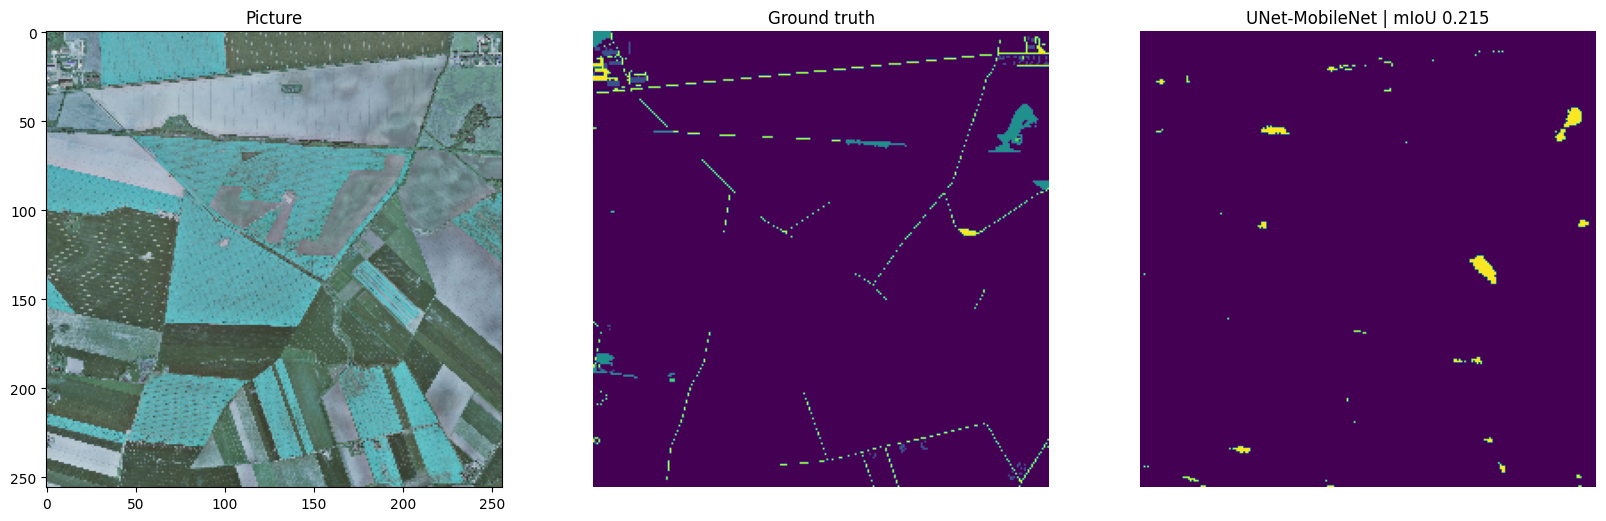

In [64]:
fig, (ax1, ax2, ax3) = plt.subplots(1,3, figsize=(20,10))
ax1.imshow(image)
ax1.set_title('Picture');

ax2.imshow(mask)
ax2.set_title('Ground truth')
ax2.set_axis_off()

ax3.imshow(pred_mask)
ax3.set_title('UNet-MobileNet | mIoU {:.3f}'.format(score))
ax3.set_axis_off()

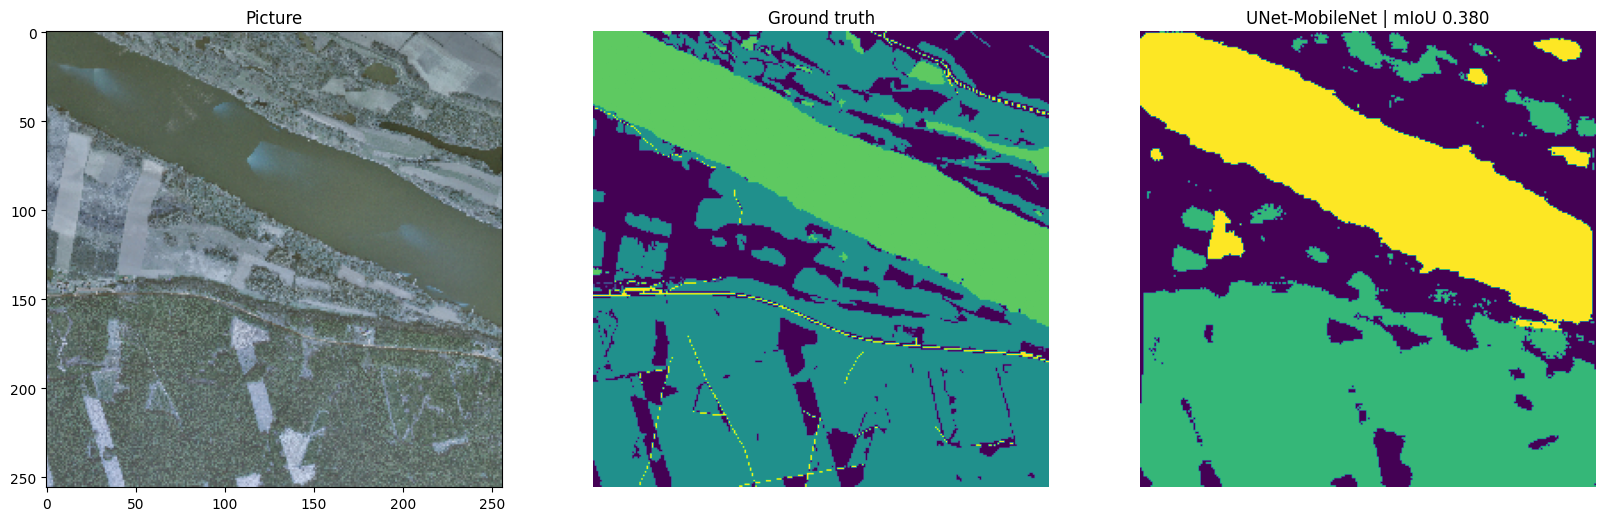

In [65]:
image2, mask2 = test_set[4]
pred_mask2, score2 = predict_image_mask_miou(model, image2, mask2)

fig, (ax1, ax2, ax3) = plt.subplots(1,3, figsize=(20,10))
ax1.imshow(image2)
ax1.set_title('Picture');

ax2.imshow(mask2)
ax2.set_title('Ground truth')
ax2.set_axis_off()

ax3.imshow(pred_mask2)
ax3.set_title('UNet-MobileNet | mIoU {:.3f}'.format(score2))
ax3.set_axis_off()

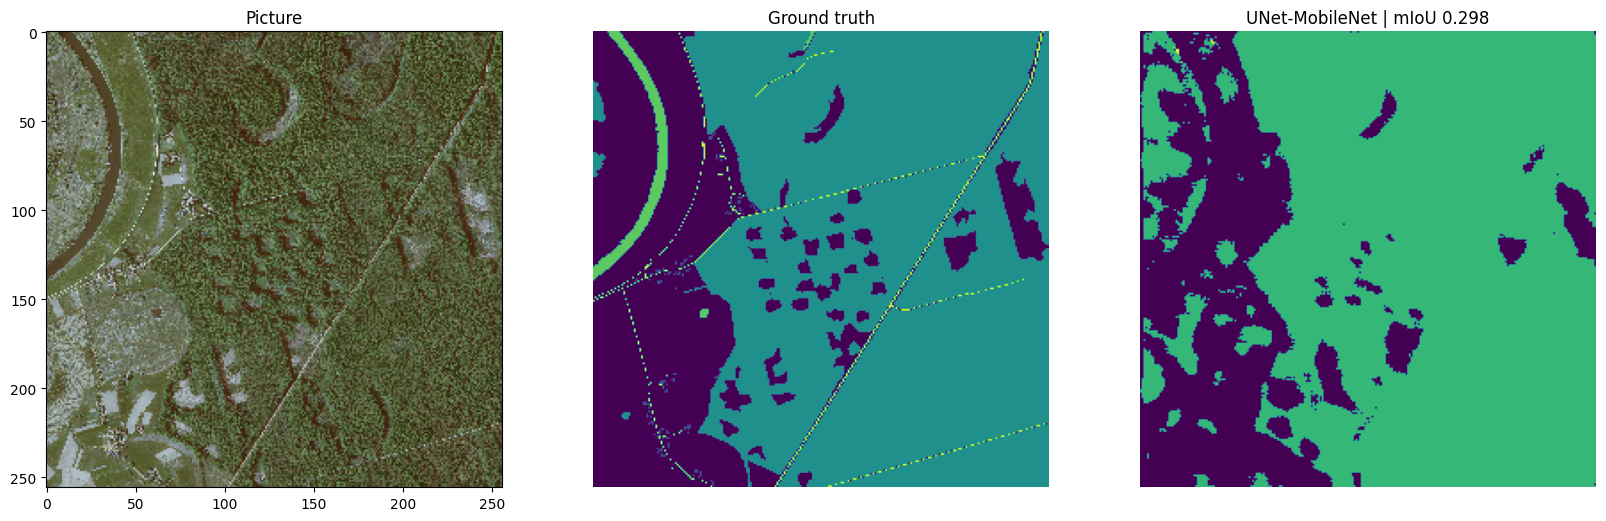

In [71]:
image3, mask3 = test_set[0]
pred_mask3, score3 = predict_image_mask_miou(model, image3, mask3)

fig, (ax1, ax2, ax3) = plt.subplots(1,3, figsize=(20,10))
ax1.imshow(image3)
ax1.set_title('Picture');

ax2.imshow(mask3)
ax2.set_title('Ground truth')
ax2.set_axis_off()

ax3.imshow(pred_mask3)
ax3.set_title('UNet-MobileNet | mIoU {:.3f}'.format(score3))
ax3.set_axis_off()

In [68]:
print('Test Set mIoU', np.mean(mob_miou))

Test Set mIoU 0.33014459605101776


In [69]:
print('Test Set Pixel Accuracy', np.mean(mob_acc))

Test Set Pixel Accuracy 0.867742919921875
